In [677]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [679]:
data=pd.read_csv("Churn_Modelling.csv")

In [681]:
data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [683]:
data=data.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [685]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [687]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [689]:
data.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [691]:
data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [693]:
y=data['Exited']
data=data.drop("Exited",axis=1)

In [695]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [697]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [699]:
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [701]:
#encoding
data['Gender']=data['Gender'].astype('category')
data['Gender']=data['Gender'].cat.codes

In [703]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58
2,502,France,0,42,8,159660.80,3,1,0,113931.57
3,699,France,0,39,1,0.00,2,0,0,93826.63
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10


In [705]:
#data['Geography']=data['Geography'].astype('Geography')
data=pd.get_dummies(data,columns=['Geography'],drop_first=True)
data=data.astype(int)


In [707]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,0,0
1,608,0,41,1,83807,1,0,1,112542,0,1
2,502,0,42,8,159660,3,1,0,113931,0,0
3,699,0,39,1,0,2,0,0,93826,0,0
4,850,0,43,2,125510,1,1,1,79084,0,1


In [709]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,0,0
1,608,0,41,1,83807,1,0,1,112542,0,1
2,502,0,42,8,159660,3,1,0,113931,0,0
3,699,0,39,1,0,2,0,0,93826,0,0
4,850,0,43,2,125510,1,1,1,79084,0,1


In [711]:
#imbalance treatment
y.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [713]:
x=data.copy()

In [715]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0,1,1,1,101348,0,0
1,608,0,41,1,83807,1,0,1,112542,0,1
2,502,0,42,8,159660,3,1,0,113931,0,0
3,699,0,39,1,0,2,0,0,93826,0,0
4,850,0,43,2,125510,1,1,1,79084,0,1


In [717]:
import imblearn 
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
x_over,y_over=sm.fit_resample(x,y)
print(y.value_counts())
print(y_over.value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
1    7963
0    7963
Name: count, dtype: int64


In [719]:
#split the data into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_over,y_over,test_size=0.2,random_state=45,stratify=y_over)

In [721]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(12740, 11)
(3186, 11)
(12740,)
(3186,)


In [723]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# Save column names and index before scaling
#cols = x_train.columns
#train_index = x_train.index
#test_index = x_test.index

# Scale training data
x_train= scaler.fit_transform(x_train)
#x_train_scaled = scaler.fit_transform(x_train)
#x_train = pd.DataFrame(x_train_scaled, columns=cols, index=train_index)

# Scale test data
x_test= scaler.transform(x_test)
#x_test_scaled = scaler.transform(x_test)
#x_test = pd.DataFrame(x_test_scaled, columns=cols, index=test_index)

In [725]:
x_train.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

<Axes: >

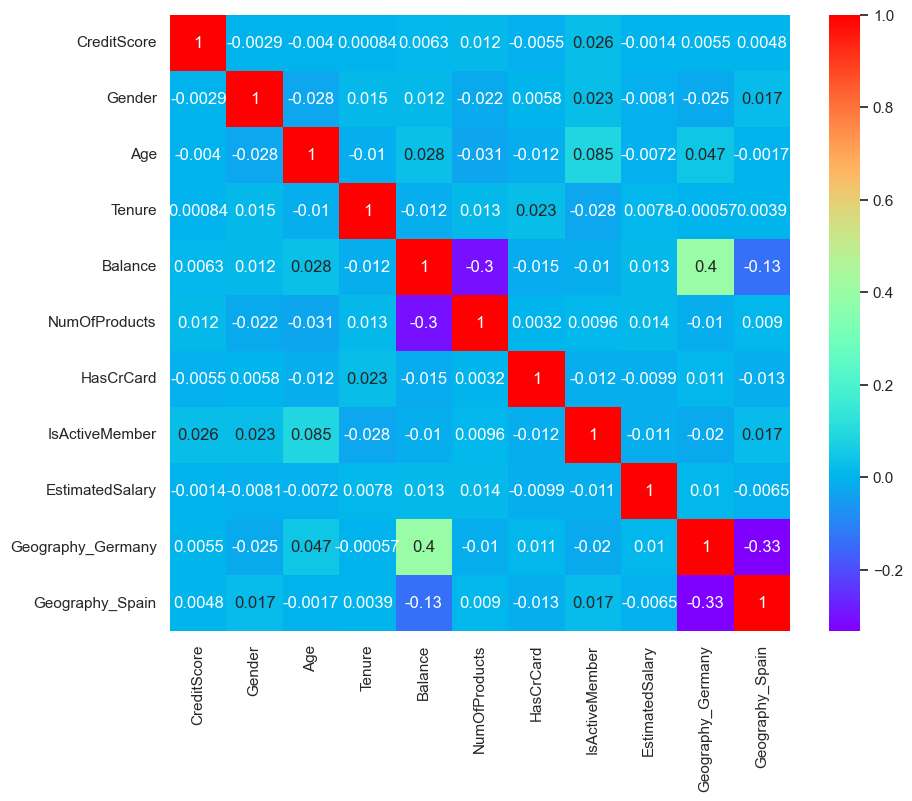

In [727]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap='rainbow')

# model Building

## Adaboost

In [731]:
from sklearn.ensemble import AdaBoostClassifier
ada=AdaBoostClassifier()
ada.fit(x_train,y_train)


AdaBoostClassifier()

In [732]:
y_pred_train_ada=ada.predict(x_train)
y_pred_test_ada=ada.predict(x_test)

In [735]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [737]:
print("confusion matrix train adaboost",confusion_matrix(y_train,y_pred_train_ada))
print("confusion matrix test adaboost",confusion_matrix(y_test,y_pred_test_ada))

confusion matrix train adaboost [[5218 1152]
 [1085 5285]]
confusion matrix test adaboost [[1294  299]
 [ 265 1328]]


In [739]:
print("classification_report train adaboost",classification_report(y_train,y_pred_train_ada))
print("classification_report test adaboost",classification_report(y_test,y_pred_test_ada))

classification_report train adaboost               precision    recall  f1-score   support

           0       0.83      0.82      0.82      6370
           1       0.82      0.83      0.83      6370

    accuracy                           0.82     12740
   macro avg       0.82      0.82      0.82     12740
weighted avg       0.82      0.82      0.82     12740

classification_report test adaboost               precision    recall  f1-score   support

           0       0.83      0.81      0.82      1593
           1       0.82      0.83      0.82      1593

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186



In [741]:
print("accuracy_score train adaboost",accuracy_score(y_train,y_pred_train_ada))
print("accuracy_score test adaboost",accuracy_score(y_test,y_pred_test_ada))

accuracy_score train adaboost 0.8244113029827316
accuracy_score test adaboost 0.8229755178907722


## Gradient boosting algorithm

In [744]:
from sklearn.ensemble import GradientBoostingClassifier
GBC=GradientBoostingClassifier()
GBC.fit(x_train,y_train)

GradientBoostingClassifier()

In [745]:
y_pred_train_GBC=GBC.predict(x_train)
y_pred_test_GBC=GBC.predict(x_test)

In [746]:
print("confusion matrix train Gradient boosting",confusion_matrix(y_train,y_pred_train_GBC))
print("confusion matrix test Gradient Boosting",confusion_matrix(y_test,y_pred_test_GBC))

confusion matrix train Gradient boosting [[5432  938]
 [1025 5345]]
confusion matrix test Gradient Boosting [[1328  265]
 [ 271 1322]]


In [747]:
print("classification_report train Gradient boosting",classification_report(y_train,y_pred_train_GBC))
print("classification_report test Gradient boosting",classification_report(y_test,y_pred_test_GBC))

classification_report train Gradient boosting               precision    recall  f1-score   support

           0       0.84      0.85      0.85      6370
           1       0.85      0.84      0.84      6370

    accuracy                           0.85     12740
   macro avg       0.85      0.85      0.85     12740
weighted avg       0.85      0.85      0.85     12740

classification_report test Gradient boosting               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1593
           1       0.83      0.83      0.83      1593

    accuracy                           0.83      3186
   macro avg       0.83      0.83      0.83      3186
weighted avg       0.83      0.83      0.83      3186



In [752]:
print("accuracy_score train Gradient boosting",accuracy_score(y_train,y_pred_train_GBC))
print("accuracy_score test Gradient boosting",accuracy_score(y_test,y_pred_test_GBC))

accuracy_score train Gradient boosting 0.8459183673469388
accuracy_score test Gradient boosting 0.8317639673571877


## XGBoost

In [755]:
from xgboost import XGBClassifier
XGB=XGBClassifier()
XGB.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [757]:
y_pred_train_XGB=XGB.predict(x_train)
y_pred_test_XGB=XGB.predict(x_test)

In [759]:
print("confusion matrix train Extra Gradient boosting",confusion_matrix(y_train,y_pred_train_XGB))
print("confusion matrix test Extra Gradient boosting",confusion_matrix(y_test,y_pred_test_XGB))

confusion matrix train Extra Gradient boosting [[5990  380]
 [ 329 6041]]
confusion matrix test Extra Gradient boosting [[1333  260]
 [ 222 1371]]


In [761]:
print("classification_report train Extra Gradient boosting",classification_report(y_train,y_pred_train_XGB))
print("classification_report test Extra Gradient boosting",classification_report(y_test,y_pred_test_XGB))

classification_report train Extra Gradient boosting               precision    recall  f1-score   support

           0       0.95      0.94      0.94      6370
           1       0.94      0.95      0.94      6370

    accuracy                           0.94     12740
   macro avg       0.94      0.94      0.94     12740
weighted avg       0.94      0.94      0.94     12740

classification_report test Extra Gradient boosting               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1593
           1       0.84      0.86      0.85      1593

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



In [763]:
print("accuracy_score train Extra Gradient boosting",accuracy_score(y_train,y_pred_train_XGB))
print("accuracy_score test Extra Gradient boosting",accuracy_score(y_test,y_pred_test_XGB))

accuracy_score train Extra Gradient boosting 0.9443485086342229
accuracy_score test Extra Gradient boosting 0.8487131198995606


## Bagging Classifier

In [766]:
from sklearn.ensemble import BaggingClassifier
bagging=BaggingClassifier()
bagging.fit(x_train,y_train)

BaggingClassifier()

In [768]:
y_pred_train_bagging=bagging.predict(x_train)
y_pred_test_bagging=bagging.predict(x_test)

In [770]:
print("confusion matrix train bagging classifier",confusion_matrix(y_train,y_pred_train_bagging))
print("confusion matrix test bagging clasifier",confusion_matrix(y_test,y_pred_test_bagging))

confusion matrix train bagging classifier [[6332   38]
 [ 104 6266]]
confusion matrix test bagging clasifier [[1352  241]
 [ 287 1306]]


In [772]:
print("classification_report train bagging classifier",classification_report(y_train,y_pred_train_bagging))
print("classification_report test bagging clasifier",classification_report(y_test,y_pred_test_bagging))

classification_report train bagging classifier               precision    recall  f1-score   support

           0       0.98      0.99      0.99      6370
           1       0.99      0.98      0.99      6370

    accuracy                           0.99     12740
   macro avg       0.99      0.99      0.99     12740
weighted avg       0.99      0.99      0.99     12740

classification_report test bagging clasifier               precision    recall  f1-score   support

           0       0.82      0.85      0.84      1593
           1       0.84      0.82      0.83      1593

    accuracy                           0.83      3186
   macro avg       0.83      0.83      0.83      3186
weighted avg       0.83      0.83      0.83      3186



In [774]:
print("accuracy_score train bagging classifier",accuracy_score (y_train,y_pred_train_bagging))
print("accuracy_score test bagging clasifier",accuracy_score (y_test,y_pred_test_bagging))

accuracy_score train bagging classifier 0.9888540031397174
accuracy_score test bagging clasifier 0.8342749529190208


## Random Forest Classifier

In [777]:
from sklearn.ensemble import RandomForestClassifier
RFC=RandomForestClassifier()
RFC.fit(x_train,y_train)

RandomForestClassifier()

In [778]:
y_pred_train_RFC=RFC.predict(x_train)
y_pred_test_RFC=RFC.predict(x_test)

In [779]:
print("confusion matrix train Random forest classifier",confusion_matrix(y_train,y_pred_train_RFC))
print("confusion matrix test Random forest clasifier",confusion_matrix(y_test,y_pred_test_RFC))

confusion matrix train Random forest classifier [[6370    0]
 [   0 6370]]
confusion matrix test Random forest clasifier [[1339  254]
 [ 214 1379]]


In [783]:
print("classification_report train Random forestclassifier",classification_report(y_train,y_pred_train_RFC))
print("classification_report test Random forest  clasifier",classification_report(y_test,y_pred_test_RFC))

classification_report train Random forestclassifier               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6370
           1       1.00      1.00      1.00      6370

    accuracy                           1.00     12740
   macro avg       1.00      1.00      1.00     12740
weighted avg       1.00      1.00      1.00     12740

classification_report test Random forest  clasifier               precision    recall  f1-score   support

           0       0.86      0.84      0.85      1593
           1       0.84      0.87      0.85      1593

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



In [785]:
print("accuracy_score train Random forest classifier",accuracy_score (y_train,y_pred_train_RFC))
print("accuracy_score test Random forest clasifier",accuracy_score (y_test,y_pred_test_RFC))

accuracy_score train Random forest classifier 1.0
accuracy_score test Random forest clasifier 0.8531073446327684


## K nearest Neighbors

In [788]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [790]:
error_rate=[]
for i in range(1,30):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    error_rate.append(np.mean(y_pred !=y_test))

In [791]:
error_rate

[0.1864406779661017,
 0.18957940991839298,
 0.18047708725674827,
 0.18236032642812303,
 0.18612680477087257,
 0.18361581920903955,
 0.18957940991839298,
 0.18612680477087257,
 0.18581293157564344,
 0.18706842435655996,
 0.18801004394224732,
 0.19052102950408034,
 0.192090395480226,
 0.19083490269930947,
 0.19428750784682988,
 0.19240426867545513,
 0.1933458882611425,
 0.1911487758945386,
 0.1958568738229755,
 0.19711236660389203,
 0.1977401129943503,
 0.19554300062774638,
 0.19522912743251727,
 0.19491525423728814,
 0.19648462021343377,
 0.19711236660389203,
 0.19742623979912116,
 0.19805398618957942,
 0.19805398618957942]

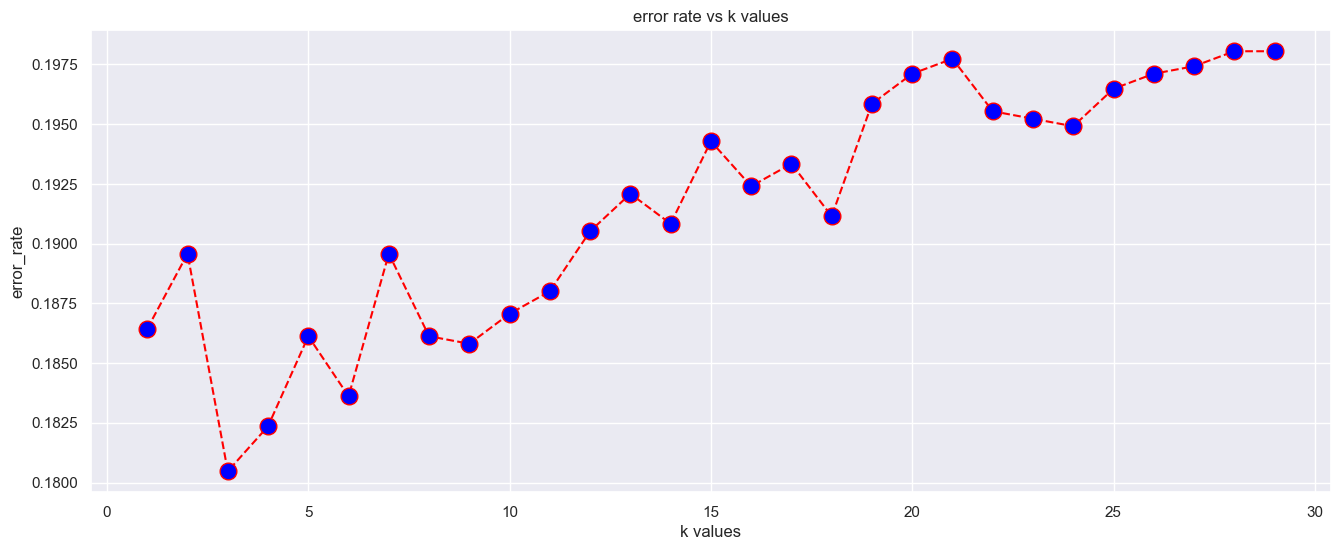

In [792]:
plt.figure(figsize=(16,6))
plt.plot(range(1,30),error_rate,color='red',linestyle='dashed',marker='o',markersize=12,markerfacecolor='blue')
plt.title('error rate vs k values')
plt.xlabel('k values')
plt.ylabel('error_rate')
plt.show()

In [793]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [794]:
y_pred_train_knn = knn.predict(x_train)
y_pred_test_knn = knn.predict(x_test)

In [795]:
print(classification_report(y_train, y_pred_train_knn))
print()
print(classification_report(y_test, y_pred_test_knn))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      6370
           1       0.88      0.92      0.90      6370

    accuracy                           0.90     12740
   macro avg       0.90      0.90      0.90     12740
weighted avg       0.90      0.90      0.90     12740


              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1593
           1       0.81      0.84      0.82      1593

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186



In [796]:
print(accuracy_score(y_train, y_pred_train_knn))
print()
print(accuracy_score(y_test, y_pred_test_knn))

0.8982731554160126

0.8195229127432517
